# Exercise 8: Instrument Recognition – Multitrack Datasets

## Imports

In [2]:
import pathlib
import random
from typing import Union

import librosa
import numpy as np
import scipy
from matplotlib import pyplot as plt
from scipy.signal import filtfilt


## Constants

In [3]:
current_dir = pathlib.Path.cwd()

# Dataset
data_path = current_dir.joinpath("data")

# File extensions
TRACKS_FILE_EXTENSION = ".wav"
MIX_FILE_EXTENSION = ".mp3"

# File paths
track_file_paths = sorted(data_path.glob(f"*{TRACKS_FILE_EXTENSION}"))
print(track_file_paths)
mix_file_path = list(data_path.glob(f"*{MIX_FILE_EXTENSION}"))
assert len(mix_file_path) == 1, f"Mix file with extension {MIX_FILE_EXTENSION} not found!"
mix_file_path = mix_file_path[0]

[PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/01_Kick.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/02_Snare.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/03_Tom1.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/04_Tom2.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/05_Overheads.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/06_Bass.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/07_ElecGtr1.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/08_ElecGtr2.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-AIiM/exercices/e8/data/09_LeadVox.wav'), PosixPath('/home/andi/Desktop/UNI STUFF/WS2526/AIM/GITREPO/RWTH-

## Read and Process Data

In [4]:
class Track:
    track_name: str

    data: np.ndarray
    sr: Union[int, float]

    length: float

    def __init__(self, path: pathlib.Path):
        self.data, self.sr = librosa.load(path)
        self.track_name = self._get_track_name_from_path(path)

        self.length = len(self.data) / self.sr

    @staticmethod
    def _get_track_name_from_path(path: pathlib.Path) -> str:
        return str(path).split("/")[-1].split(".")[0]

    def __str__(self):
        return f"Track({self.track_name}, sr={self.sr}, length={self.length:.1f})"


tracks = []
for track_file_path in track_file_paths:
    tracks.append(Track(track_file_path))

mix = Track(mix_file_path)

In [5]:
print("Tracks:")
for track in tracks:
    print(track)
print("Mix:")
print(mix)

Tracks:
Track(01_Kick, sr=22050, length=205.0)
Track(02_Snare, sr=22050, length=205.0)
Track(03_Tom1, sr=22050, length=205.0)
Track(04_Tom2, sr=22050, length=205.0)
Track(05_Overheads, sr=22050, length=205.0)
Track(06_Bass, sr=22050, length=205.0)
Track(07_ElecGtr1, sr=22050, length=205.0)
Track(08_ElecGtr2, sr=22050, length=205.0)
Track(09_LeadVox, sr=22050, length=205.0)
Track(10_BackingVox1, sr=22050, length=205.0)
Track(11_BackingVox2, sr=22050, length=205.0)
Mix:
Track(Juanita Dientes Verdes_Placido Domingo_mix, sr=22050, length=204.9)


## E1: Visualisation

In [6]:
class TrackSection:
    start_time: float
    end_time: float

    def __init__(self, start_time: float, end_time: float):
        assert start_time >= 0, f"start_time is negative! ({start_time})"
        assert end_time > 0, f"end_time is non-positive! ({end_time})"
        assert start_time < end_time, f"start_time should be less than end_time! - ({start_time}-{end_time})"

        self.start_time: float = start_time
        self.end_time: float = end_time

    def __str__(self):
        return f"TrackSection(start_time={self.start_time:.1f}, end_time={self.end_time:.1f})"


def get_random_track_section(track_length: float) -> TrackSection:
    start_time: float = random.uniform(0, track_length)
    while start_time == track_length:
        start_time = random.uniform(0, track_length)
    end_time: float = start_time
    while start_time == end_time:
        end_time = random.uniform(start_time, track_length)
    return TrackSection(start_time, end_time)


def plot_highlighted_waveform(track: Track, sections_to_highlight: list[TrackSection] = None,
                              figure_size: tuple[int, int] = (16, 4), title: str = None, highlight_color: str = "red",
                              highlight_alpha: float = 0.3):
    if title is None:
        title = f"Waveform for track: {track.track_name}"
    if sections_to_highlight is None:
        sections_to_highlight = []

    # Print waveform
    plt.figure(figsize=figure_size)
    librosa.display.waveshow(track.data, sr=track.sr)
    plt.title(title)
    plt.xlabel("Time (m:s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()

    # Add sections
    ax = plt.gca()
    for section in sections_to_highlight:
        ax.axvspan(section.start_time, section.end_time, color=highlight_color, alpha=highlight_alpha)

    plt.show()


# Uncomment to visualize plot examples
if False:
    for track in tracks:
        plot_highlighted_waveform(track, [get_random_track_section(track.length)])
    plot_highlighted_waveform(mix)

## E2: Instrument Activity Detection

In [7]:
def get_original_time(frame_idx: int, frame_length: int = 4096, hop_length: int = 2048, sr: int = 22050) -> tuple[
    float, float]:
    assert frame_idx >= 0, "frame_idx should be non-negative!"

    start_sample = frame_idx * hop_length
    end_sample = start_sample + frame_length - 1
    return start_sample / sr, end_sample / sr


def get_track_activations(activations: np.ndarray, frame_length: int = 4096, hop_length: int = 2048, sr: int = 22050) -> \
        list[list[TrackSection]]:
    track_sections = []
    for track_activations in activations:
        track_section = []
        init_frame_idx = -1
        end_frame_idx = -1
        for frame_idx, frame in enumerate(track_activations):
            if frame:
                if init_frame_idx == -1:
                    init_frame_idx = frame_idx
                    end_frame_idx = frame_idx
                else:
                    end_frame_idx = frame_idx
            else:
                if end_frame_idx != -1:
                    track_section.append(TrackSection(
                        get_original_time(init_frame_idx, frame_length=frame_length, hop_length=hop_length, sr=sr)[0],
                        get_original_time(end_frame_idx, frame_length=frame_length, hop_length=hop_length, sr=sr)[1]
                    ))
                    init_frame_idx = -1
                    end_frame_idx = -1
        if end_frame_idx != -1:
            track_section.append(TrackSection(
                get_original_time(init_frame_idx, frame_length=frame_length, hop_length=hop_length, sr=sr)[0],
                get_original_time(end_frame_idx, frame_length=frame_length, hop_length=hop_length, sr=sr)[1]
            ))
        track_sections.append(track_section)

    return track_sections


def detect_instrument_activity(track_list: list[Track], theta: float = 1.0, lam: float = 1.0, verbose: bool = False) -> \
        list[
            list[TrackSection]]:
    """
    STEPS:
    1. Split the track into half-overlapping frames of size 4096.
    2. Apply half-wave rectification.
    3. Calculate the energy in each frame.
    4. Normalise the energy per track within the range of [0,1].
    5. Apply a low-pass filter to smoothen the energy across frames.
    6. Calculate activation confidences with the following logistic function:
    7. Consider frames for which C(i,t) ≥ 0.5 as active, and all other frames as inactive.


    :param track_list: List of tracks. Shape [n]
    :param theta: Omega parameter for activation confidence - controls the slope of the function
    :param lam: Lambda parameter for activation confidence - controls the threshold of activation
    :param verbose:
    :return: List of TrackSections per Track. Shape [n, s]
    """

    tracks = np.stack([t.data for t in track_list])
    if verbose:
        print(f"Tracks shape: {tracks.shape}")  # [n_tracks, n_samples]

    frame_length = 4096
    hop_length = frame_length // 2  # 2048
    frames = np.stack([librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length) for y in tracks])
    if verbose:
        print(f"Frames shape: {frames.shape}")  # [n_tracks, frame_size, n_frames]

    rectified = np.maximum(frames, 0.0)
    if verbose:
        print(f"Rectified shape: {rectified.shape}")  # [n_tracks, frame_size, n_frames]

    energies = np.sum(rectified ** 2, axis=1)
    if verbose:
        print(f"Energies shape: {energies.shape}")  # [n_tracks, n_frames]

    normalized_energies = energies / np.max(energies, axis=1, keepdims=True)
    if verbose:
        print(f"Normalized energies shape: {normalized_energies.shape}")  # [n_tracks, n_frames]

    b, a = scipy.signal.butter(2, 0.075, "lowpass", analog=False)
    smoothed_energy = filtfilt(b, a, normalized_energies)
    if verbose:
        print(f"Smoothed energies shape: {smoothed_energy.shape}")  # [n_tracks, n_frames]

    confidences = 1 - 1 / (1 + lam * np.exp(smoothed_energy - theta))
    if verbose:
        print(f"Confidence shape: {confidences.shape}")  # [n_tracks, n_frames]

    activations = confidences >= 0.5
    if verbose:
        print(f"Activation confidences shape: {activations.shape}")  # [n_tracks, n_frames]

    return get_track_activations(activations, frame_length=frame_length, hop_length=hop_length,
                                 sr=track_list[0].sr)

In [ ]:
thetas = [0.01, 0.05, 0.09,
          0.1]  # Should be close to the energy median -> #[0.18375997 0.11416612 0.01392798 0.03856024 0.12297964 0.22212312 0.16027329 0.11743905 0.0457685  0.00115279 0.00441481]
lambdas = [1, 3, 5]  # Values between 5-30 should be good

exps = len(thetas) * len(lambdas)

exp = 0
for theta in thetas:
    for lam in lambdas:
        print(f"Checking activations for theta={theta}, lam={lam}. [{exp + 1} of {exps} - {exp / exps * 100:.1f}%]")
        track_sections = detect_instrument_activity(tracks, theta=theta, lam=lam)
        count = sum([len(sections) for sections in track_sections])
        if count == 0:
            print("No activations found. Skipping.")
        elif count == 11:
            print("Suspicious activity found (count=11). Skipping.")
        else:
            print(f"Activation count: {count}")
            for idx, track in enumerate(tracks):
                plot_highlighted_waveform(track, track_sections[idx])
        print()
        exp += 1


Checking activations for theta=0.001, lam=1. [1 of 24 - 0.0%]
Activation count: 64

Checking activations for theta=0.001, lam=3. [2 of 24 - 4.2%]
Suspicious activity found (count=11). Skipping.

Checking activations for theta=0.001, lam=5. [3 of 24 - 8.3%]
Suspicious activity found (count=11). Skipping.

Checking activations for theta=0.01, lam=1. [4 of 24 - 12.5%]
Activation count: 75

Checking activations for theta=0.01, lam=3. [5 of 24 - 16.7%]
Suspicious activity found (count=11). Skipping.

Checking activations for theta=0.01, lam=5. [6 of 24 - 20.8%]
Suspicious activity found (count=11). Skipping.

Checking activations for theta=0.05, lam=1. [7 of 24 - 25.0%]
Activation count: 98

Checking activations for theta=0.05, lam=3. [8 of 24 - 29.2%]
Suspicious activity found (count=11). Skipping.

Checking activations for theta=0.05, lam=5. [9 of 24 - 33.3%]
Suspicious activity found (count=11). Skipping.

Checking activations for theta=0.09, lam=1. [10 of 24 - 37.5%]
Activation count: 1

In [28]:
"""
import matplotlib.pyplot as plt
import numpy as np

# Wir erzeugen 50 gleichmäßig verteilte Punkte zwischen 0 und 0.4
# Das gibt eine viel feinere Auflösung als die manuelle Liste zuvor.
thetas = np.linspace(0.01, 0.4, 50)
fixed_lam = 1  # Lambda bleibt fix auf 1

counts = []

print(f"Sammle Daten für {len(thetas)} Theta-Werte (lambda={fixed_lam})...")

for i, theta in enumerate(thetas):
    # Status-Update alle 10 Schritte, damit man sieht, dass es noch läuft
    if i % 10 == 0:
        print(f"Fortschritt: {i}/{len(thetas)}...")

    # Aktivitätserkennung ausführen
    # Hinweis: detect_instrument_activity und tracks müssen bereits definiert sein
    track_sections = detect_instrument_activity(tracks, theta=theta, lam=fixed_lam)
    
    # Gesamtzahl der Aktivierungen über alle Tracks hinweg berechnen
    count = sum([len(sections) for sections in track_sections])
    counts.append(count)

print("Berechnung abgeschlossen. Erstelle Plot...")

# Plot erstellen
plt.figure(figsize=(12, 6))

# Plotten der Kurve
plt.plot(thetas, counts, color='blue', linewidth=2, label='Aktivierungen')

# Den Bereich unter der Kurve füllen, damit es hübscher aussieht
plt.fill_between(thetas, counts, color='blue', alpha=0.1)

# Den maximalen Punkt (Peak) markieren
max_count = max(counts)
max_theta = thetas[counts.index(max_count)]
plt.plot(max_theta, max_count, 'ro', label=f'Peak (theta={max_theta:.2f})')

plt.title(f'Aktivierungsverlauf über Theta (lambda={fixed_lam})', fontsize=14)
plt.xlabel('Theta (Schwellenwert)', fontsize=12)
plt.ylabel('Anzahl gefundener Aktivierungen', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
"""

'\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Wir erzeugen 50 gleichmäßig verteilte Punkte zwischen 0 und 0.4\n# Das gibt eine viel feinere Auflösung als die manuelle Liste zuvor.\nthetas = np.linspace(0.01, 0.4, 50)\nfixed_lam = 1  # Lambda bleibt fix auf 1\n\ncounts = []\n\nprint(f"Sammle Daten für {len(thetas)} Theta-Werte (lambda={fixed_lam})...")\n\nfor i, theta in enumerate(thetas):\n    # Status-Update alle 10 Schritte, damit man sieht, dass es noch läuft\n    if i % 10 == 0:\n        print(f"Fortschritt: {i}/{len(thetas)}...")\n\n    # Aktivitätserkennung ausführen\n    # Hinweis: detect_instrument_activity und tracks müssen bereits definiert sein\n    track_sections = detect_instrument_activity(tracks, theta=theta, lam=fixed_lam)\n\n    # Gesamtzahl der Aktivierungen über alle Tracks hinweg berechnen\n    count = sum([len(sections) for sections in track_sections])\n    counts.append(count)\n\nprint("Berechnung abgeschlossen. Erstelle Plot...")\n\n# Plot erstellen

<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:56: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230/247590669.py:56: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'$\lambda = {lam}$', fontsize=12, fontweight='bold')


Starting calculation for 7 lambdas with 1000 thetas each...
Total computations: 7000

[1/7] Processing Lambda = 0...
[2/7] Processing Lambda = 0.1...
[3/7] Processing Lambda = 0.5...
[4/7] Processing Lambda = 0.75...
[5/7] Processing Lambda = 1...
[6/7] Processing Lambda = 5...
[7/7] Processing Lambda = 10...


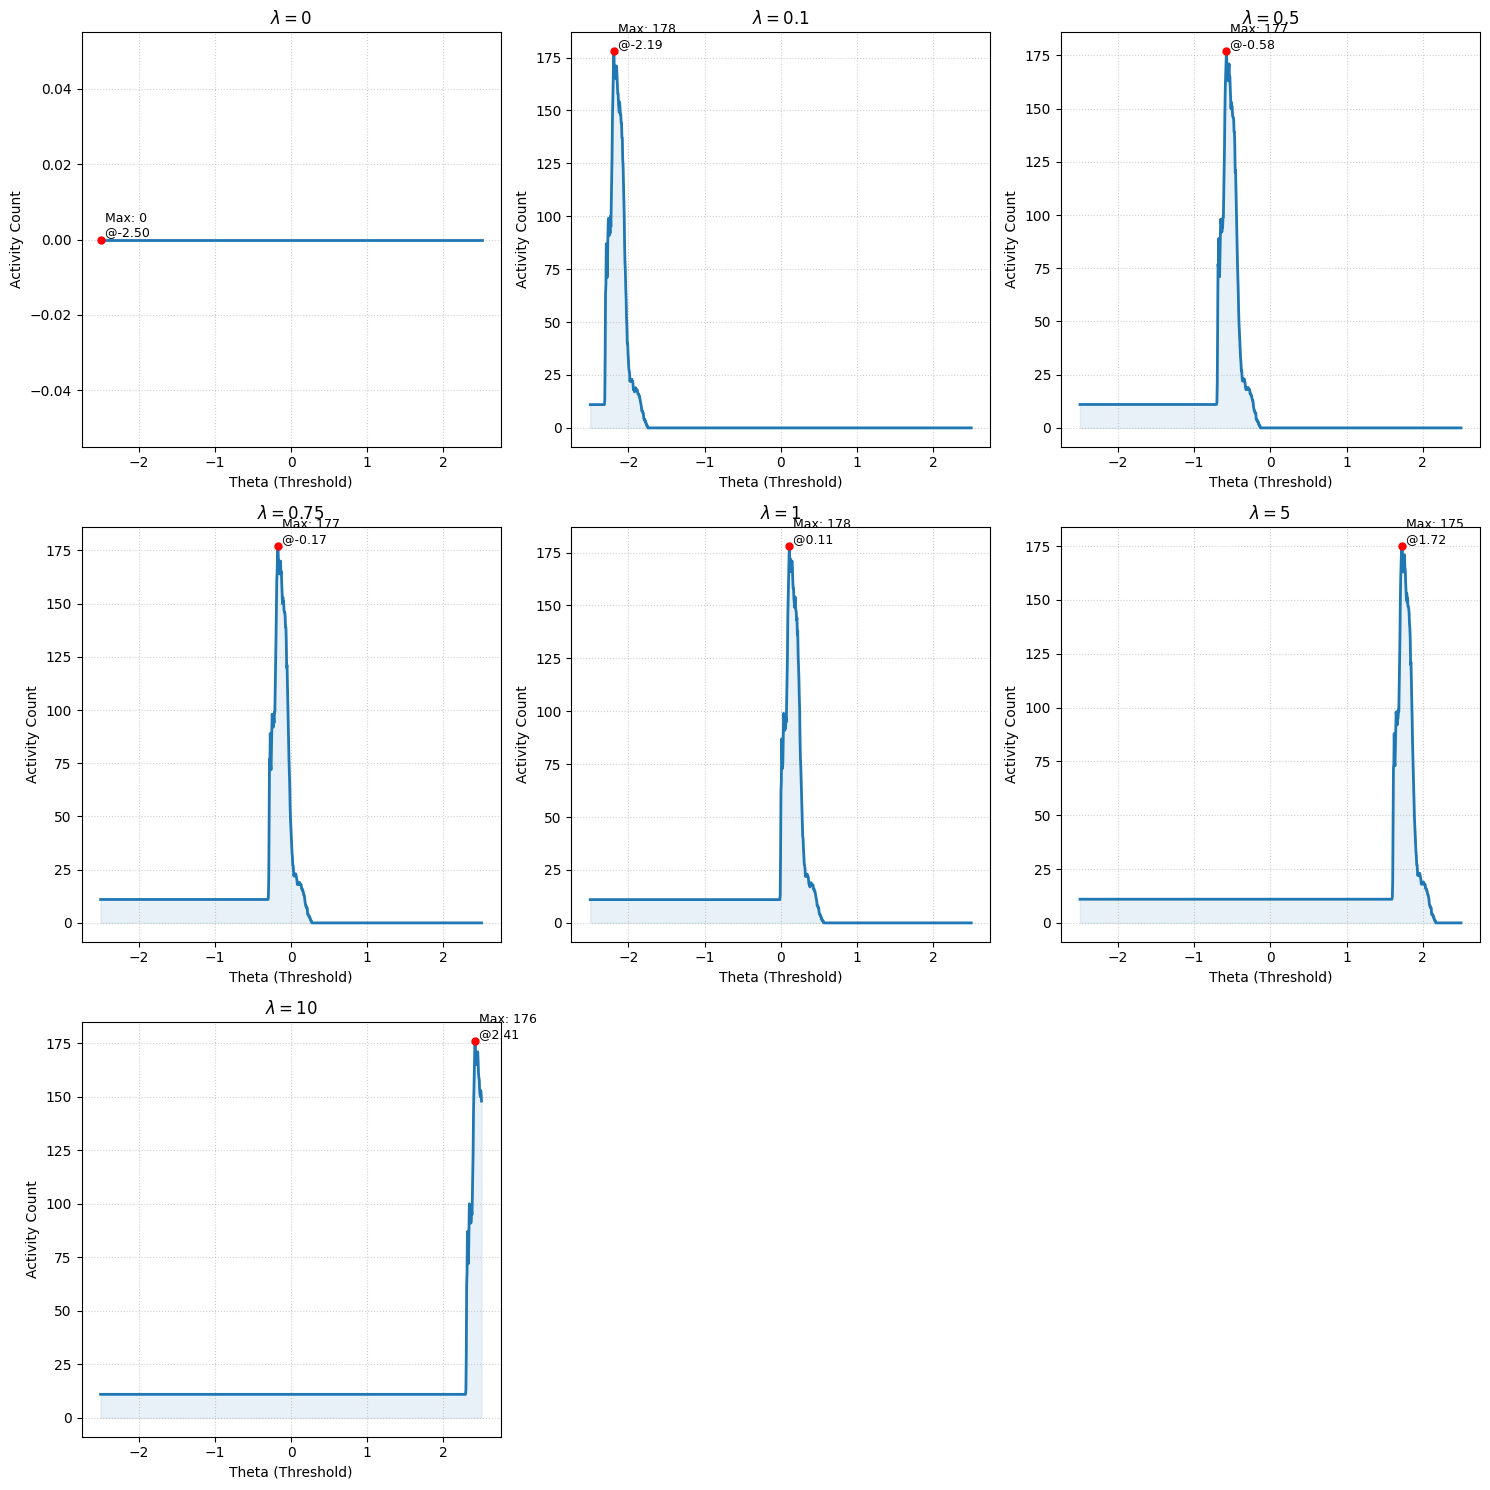

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Define Parameters
# 100 steps between 0.01 and 0.6 for smoother curves
#thetas = np.linspace(0.01, 0.6, 100)
thetas = np.linspace(-5,5,1000)

# Various lambda values to test
lambdas = [0.1, 0.5, 0.75, 1, 1.5, 2, 5, 10, 20]

# 2. Calculate Dynamic Layout
num_plots = len(lambdas)
cols = 3                            # Number of columns
rows = math.ceil(num_plots / cols)  # Calculate required rows

# Create Figure
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() 

print(f"Starting calculation for {len(lambdas)} lambdas with {len(thetas)} thetas each...")
print(f"Total computations: {len(lambdas) * len(thetas)}\n")

# 3. Loop over Lambdas
for i, lam in enumerate(lambdas):
    ax = axes[i]
    counts = []
    
    # Status update
    print(f"[{i+1}/{num_plots}] Processing Lambda = {lam}...")

    # Loop over Thetas
    for theta in thetas:
        # YOUR FUNCTION CALL HERE
        track_sections = detect_instrument_activity(tracks, theta=theta, lam=lam)
        
        # Summing up found activities
        count = sum([len(sections) for sections in track_sections])
        counts.append(count)

    # --- Plotting ---
    ax.plot(thetas, counts, color='#1f77b4', linewidth=2)
    ax.fill_between(thetas, counts, color='#1f77b4', alpha=0.1)

    # Mark Peak
    if len(counts) > 0:
        max_count = max(counts)
        max_theta = thetas[counts.index(max_count)]
        ax.plot(max_theta, max_count, 'ro', markersize=5)
        # Annotation in English
        ax.text(max_theta, max_count, f' Max: {max_count}\n @{max_theta:.2f}', 
                verticalalignment='bottom', fontsize=9)

    # English Labels
    ax.set_title(f'$\lambda = {lam}$', fontsize=12, fontweight='bold')
    ax.set_xlabel('Theta (Threshold)')
    ax.set_ylabel('Activity Count')
    ax.grid(True, linestyle=':', alpha=0.6)

# 4. Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## E3: Audio Bleed

In [9]:
# TODO: !!